# Experiment No: 5
**Aim**: To implement a Decision Tree Classifier on the Spambase dataset, visualize the resulting tree structure, and evaluate its classification performance.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("--- Step 1 & 2: Load Data and Split ---")
spambase = fetch_ucirepo(id=94)
X = spambase.data.features
y = spambase.data.targets.values.ravel()

# Decision Trees don't strictly require feature scaling, so we use raw X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data split successfully: {X_train.shape[0]} train rows, {X_test.shape[0]} test rows.")

--- Step 1 & 2: Load Data and Split ---
Data split successfully: 3680 train rows, 921 test rows.


In [5]:
print("--- Step 3 & 4: Model Training ---")
# Setting max_depth=3 to keep the tree readable when we plot it
dt_model = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree training complete.\n")

print("--- Step 5: Evaluation ---")
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

--- Step 3 & 4: Model Training ---
Decision Tree training complete.

--- Step 5: Evaluation ---
Decision Tree Accuracy: 86.64%

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.88      0.89      0.88       531
        Spam       0.84      0.84      0.84       390

    accuracy                           0.87       921
   macro avg       0.86      0.86      0.86       921
weighted avg       0.87      0.87      0.87       921



--- Step 6: Visualizing the Decision Tree ---


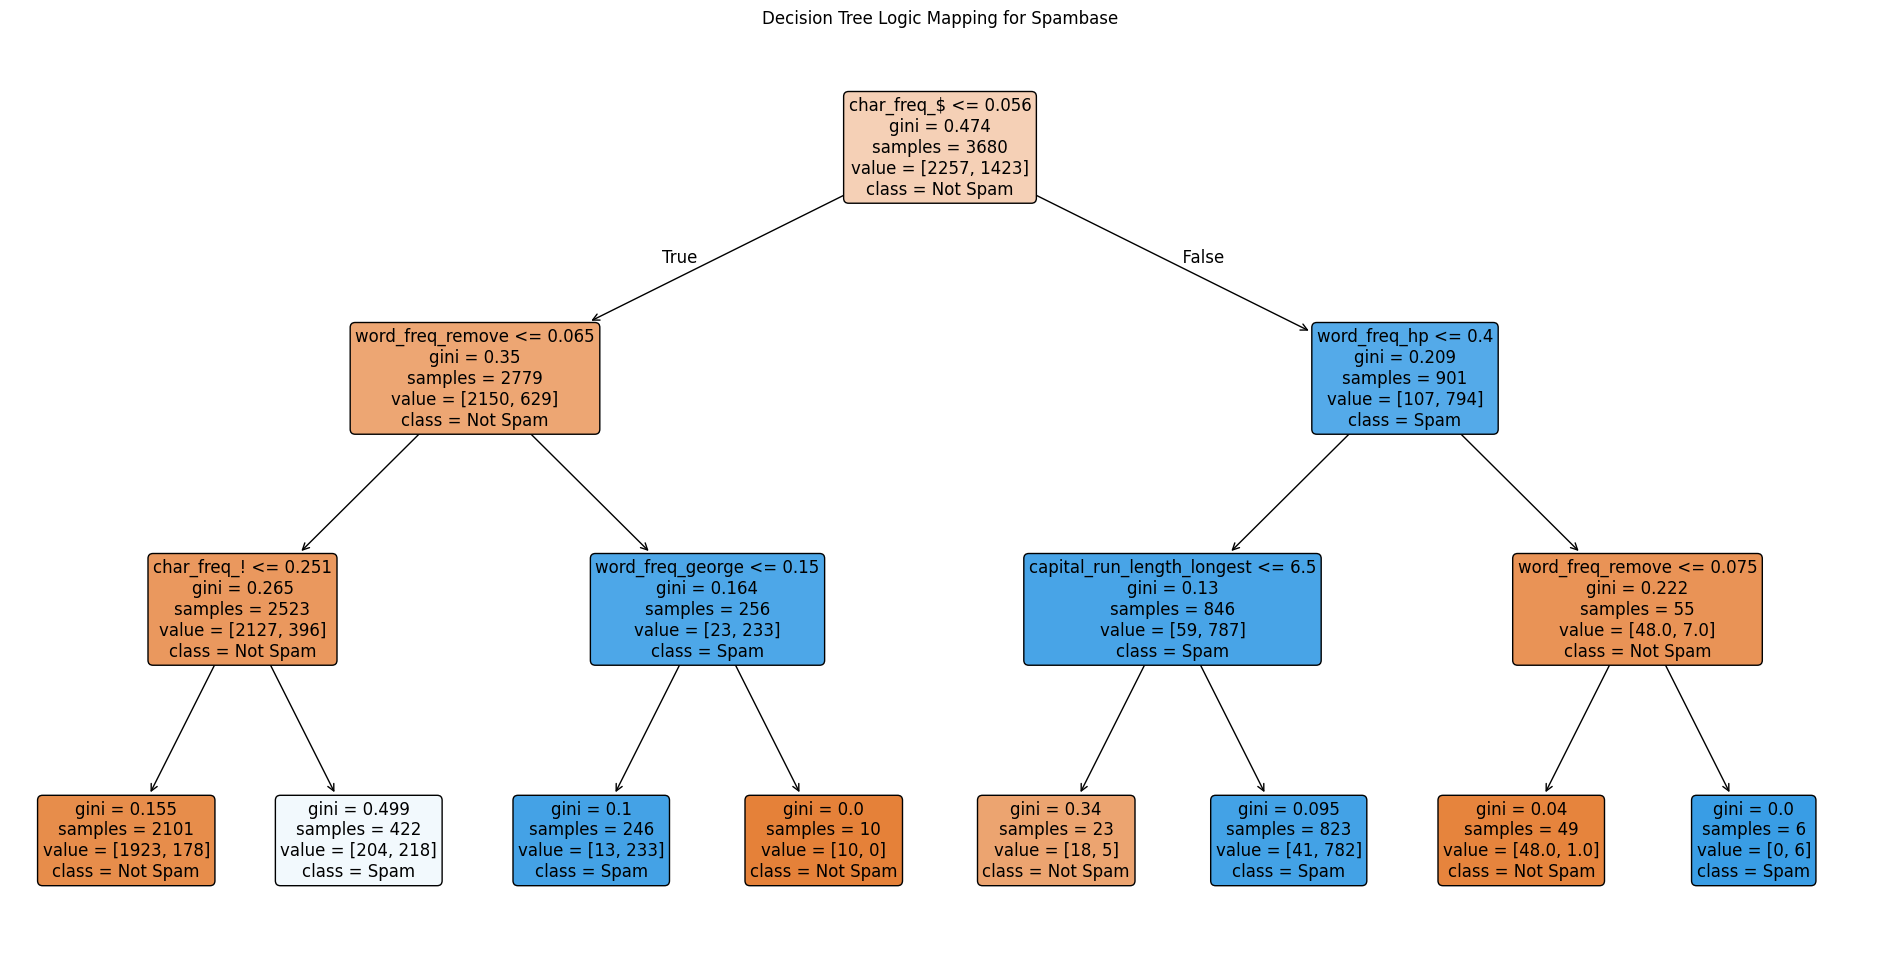

In [6]:
print("--- Step 6: Visualizing the Decision Tree ---")
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Not Spam', 'Spam'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title('Decision Tree Logic Mapping for Spambase')
plt.show()